The hometask is open-ended and i want to learn more about SVM, so i will code it from scratch

In [142]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

In [143]:
X, y = make_blobs(n_samples=100, centers=2, cluster_std=3.5, random_state=42)
X.shape, y.shape, X[:5], y[:5]

((100, 2),
 (100,),
 array([[-4.18630746,  8.36447971],
        [ 8.43055819,  5.66147687],
        [-4.41453716,  9.40251519],
        [ 7.5170894 ,  8.61194512],
        [ 5.43598861,  6.54816932]]),
 array([0, 1, 0, 1, 1]))

In [144]:
y = y*2. - 1
y[:5]

array([-1.,  1., -1.,  1.,  1.])

In [145]:
np.random.seed(42)

w = np.random.rand(2,)
b = np.random.rand()

w, b

(array([0.37454012, 0.95071431]), 0.7319939418114051)

In [146]:
def predict(X, w, b):
    m = X.shape[0]
    y_pred = np.zeros(m)
    for i in range(m):
        y_pred[i] = np.dot(w, X[i]) + b
    y_pred = np.sign(y_pred)
    return y_pred 

In [147]:
predict(X[:10], w, b)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [148]:
def plot_true_and_pred(X, y, w, b):
    #limits for plot vertically and horizontally
    xlim = np.array([X[:, 0].min()-1, X[:, 0].max()+1])
    ylim = np.array([X[:, 1].min()-1, X[:, 1].max()+1])

    plt.figure(figsize=(4,3))
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.title("y_true")
    plt.xlim(xlim[0], xlim[1])
    plt.ylim(ylim[0], ylim[1])

    plt.figure(figsize=(4,3))
    y_pred = predict(X, w, b)
    plt.scatter(X[:, 0], X[:, 1], c=y_pred)
    plt.title("y_pred")
    plt.xlim(xlim[0], xlim[1])
    plt.ylim(ylim[0], ylim[1])

    #decision boundary
    xx = xlim
    yyn = (-1 - b - (w[0] * xx)) / w[1]
    yym = (-b - (w[0] * xx)) / w[1]
    yyp = (1 - b - (w[0] * xx)) / w[1]

    plt.plot(xx, yyn, color='red', linestyle='dotted')
    plt.plot(xx, yym, color='black')
    plt.plot(xx, yyp, color='blue', linestyle='dotted')


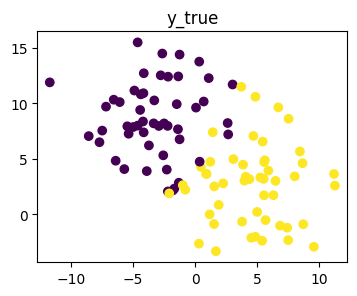

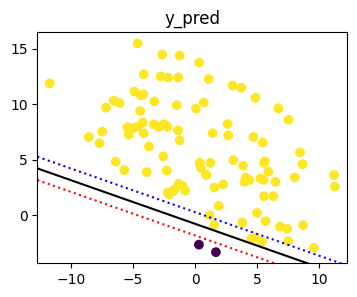

In [149]:
plot_true_and_pred(X, y, w, b)

In [150]:
#Calculate Hinge Loss

def calc_hinge(X_i, y_i, w, b):
    return max(0, 1 - y_i * (np.dot(w, X_i) + b))

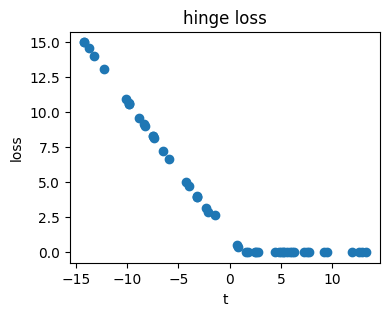

In [151]:
n_examples = 50
t = np.zeros(n_examples)
loss = np.zeros(n_examples)

for i in range(n_examples):
    t[i] = y[i] * np.dot(w, X[i] + b)
    loss[i] = calc_hinge(X[i], y[i],    w, b)

plt.figure(figsize=(4,3))
plt.scatter(t, loss)
plt.title("hinge loss")
plt.xlabel("t")
plt.ylabel("loss")
plt.show()

In [152]:
def J(X, y, w, b, C=1):
    m = X.shape[0]
    
    margin_loss = (np.dot(w, w)**2) /2 # squared the vector length of weight vector for better derivative later
    hinge_loss = 0
    for i in range(m):
        loss_i = calc_hinge(X[i], y[i], w, b)
        hinge_loss += loss_i
    hinge_loss *= C
    
    total_loss = margin_loss + hinge_loss
    return total_loss


In [153]:
J(X, y, w, b)

442.79701081354773

In [154]:
def calc_gradient(X, y, w, b, C=1):
    n = X.shape[1]
    m = X.shape[0]

    dj_w = np.zeros(n)
    dj_b = 0.
    
    for i in range(m):
        hinge_condition = (1 - y[i] * (np.dot(w, X[i]) + b)) > 0
        if hinge_condition:
            dj_w -= (C * y[i] * X[i])
            dj_b -= C * y[i]
    dj_w += w
    return dj_w, dj_b

In [155]:
dj_w, dj_b = calc_gradient(X, y, w, b)
dj_w, dj_b

(array([-177.25171872,  443.32580276]), 44.0)

In [156]:
alpha = 0.001

w_new = w - alpha * dj_w
b_new = b - alpha * dj_b

print(f"Before: {J(X, y, w, b,)}\nAfter: {J(X, y, w_new, b_new)}")

Before: 442.79701081354773
After: 217.3486638430651


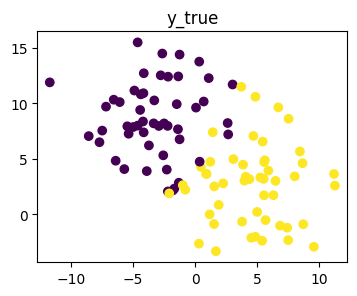

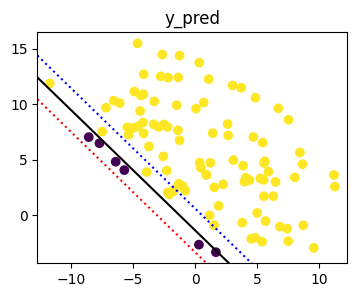

In [157]:
plot_true_and_pred(X,y, w_new, b_new)

gradient calculated correctly, now can create fitting loop

In [158]:
def fit(X, y, w, b, n_iters=10, C=1, alpha=0.001, history_step=1):
    history = {}
    for iter in range(n_iters):
        dj_w, dj_b = calc_gradient(X, y, w, b, C)
        w = w - alpha * dj_w
        b = b - alpha * dj_b

        if iter % history_step == 0:
            cost = J(X, y, w, b, C)
            print(f"iter\t{iter}\tCost\t{cost}")
            history[iter] = cost
    return history, w, b

In [159]:
history, w_new, b_new = fit(X, y, w, b)

iter	0	Cost	217.3486638430651
iter	1	Cost	44.29195579722699
iter	2	Cost	16.978564097536662
iter	3	Cost	15.481364652478874
iter	4	Cost	15.04324694475561
iter	5	Cost	15.011904580229576
iter	6	Cost	14.979177561927045
iter	7	Cost	14.951854246233564
iter	8	Cost	14.94174039078932
iter	9	Cost	14.909170693478945


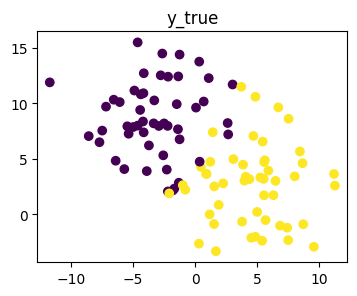

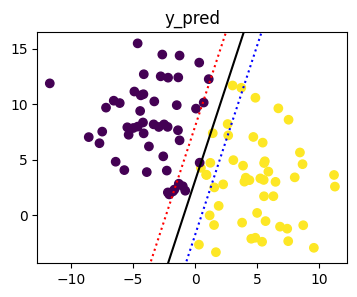

In [162]:
plot_true_and_pred(X, y, w_new, b_new)

In [160]:
def plot_history(history):
    plt.figure(figsize=(4,3))
    plt.plot(history.keys(), history.values())
    plt.title("Loss over iterations")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")

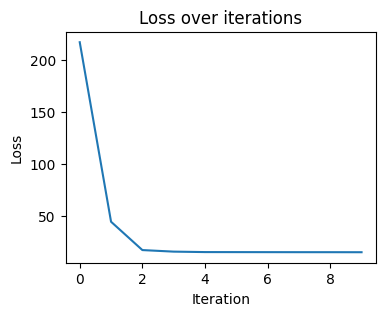

In [161]:
plot_history(history)

We can see that function converges really fast, because the data is really easy, there only 2 classes(SVM can solve multiclass problems using techniques like one-vs-rest or one-vs-one, but then we need to train at least k classifiers for k classes) and only 2 features.